### Time Series Output 


In [ ]:
import sys
from pathlib import Path

# Add workspace root to path
workspace_root = Path.cwd().parent  # Goes up one level from Tech_Index
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

# Now import
from Data_Source.get_price import get_yahoo_data_comprehensive

# Use it
df = get_yahoo_data_comprehensive("BMNR", 300)
print(df.tail()) 

📊 Fetching 300 days of comprehensive data for BMNR...
✅ Retrieved 90 days
   Range: 2025-06-05 → 2025-10-13
   Latest Close: $56.85
   Latest High: $56.85
   Latest Low: $52.70
         date       open       high        low      close    volume
85 2025-10-07  65.000000  65.599998  58.580002  59.200001  69952200
86 2025-10-08  60.529999  61.009998  57.119999  60.000000  51600500
87 2025-10-09  59.070000  59.310001  56.509998  59.099998  40909700
88 2025-10-10  59.240002  60.939999  52.365002  52.470001  66392200
89 2025-10-13  54.209999  56.849998  52.700001  56.849998  41011545


/Users/xikinki/Desktop/Ringshell_AI/Ringshell_source_code/Data_Source/get_price.py:99: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


### SMC Index

In [114]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def plot_smc_chart(
    df: pd.DataFrame,
    show_candles: 
    bool = True,
    show_swings: bool = True,
    show_bos: bool = True,
    show_order_blocks: bool = True,
    show_equal_high_low: bool = True,
    show_fvg: bool = True,
    show_zones: bool = True,
):
    """
    Smart Money Concepts Visualization (Full Version)
    - Candles
    - Swing Highs/Lows
    - BOS / CHoCH
    - Order Blocks
    - Equal Highs/Lows
    - Fair Value Gaps (FVG)
    - Premium/Discount Zones
    """

    # --- Clean data
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # --- Compute trend direction
    df['trend'] = np.where(df['close'] > df['open'], 'bull', 'bear')

    # --- Swing highs/lows detection
    df['swing_high'] = df['high'][(df['high'] > df['high'].shift(1)) &
                                  (df['high'] > df['high'].shift(-1))]
    df['swing_low']  = df['low'][(df['low']  < df['low'].shift(1)) &
                                 (df['low']  < df['low'].shift(-1))]

    # --- Structure points (BOS / CHoCH)
    structure_points = []
    last_trend = None
    last_high = None
    last_low = None

    for i in range(len(df)):
        high = df.loc[i, 'swing_high']
        low = df.loc[i, 'swing_low']
        date = df.loc[i, 'date']

        # Bullish BOS
        if pd.notna(high) and last_high is not None:
            if high > last_high:
                label = 'CHoCH ↑' if last_trend == 'bearish' else 'BOS ↑'
                structure_points.append((i, date, high, label))
                last_trend = 'bullish'
            last_high = high

        # Bearish BOS
        if pd.notna(low) and last_low is not None:
            if low < last_low:
                label = 'CHoCH ↓' if last_trend == 'bullish' else 'BOS ↓'
                structure_points.append((i, date, low, label))
                last_trend = 'bearish'
            last_low = low

        # Initialize
        if pd.notna(high) and last_high is None:
            last_high = high
        if pd.notna(low) and last_low is None:
            last_low = low

    # --- Order Blocks
    order_blocks = []
    for i, (idx, date, price, label) in enumerate(structure_points):
        if 'BOS' in label:
            prev_idx = max(idx - 1, 0)
            prev = df.loc[prev_idx]
            start_date = prev['date']
            end_date = df['date'].iloc[-1]

            if '↑' in label:
                order_blocks.append((start_date, end_date, prev['low'], prev['high'], 'bullish'))
            else:
                order_blocks.append((start_date, end_date, prev['low'], prev['high'], 'bearish'))

    # --- Equal Highs / Lows (EQH / EQL)
    eq_levels = []
    threshold = 0.1  # ~0.1% price tolerance
    if show_equal_high_low:
        for i in range(1, len(df)):
            if abs(df.loc[i, 'high'] - df.loc[i - 1, 'high']) / df.loc[i, 'high'] < threshold:
                eq_levels.append((df.loc[i, 'date'], df.loc[i, 'high'], 'EQH'))
            if abs(df.loc[i, 'low'] - df.loc[i - 1, 'low']) / df.loc[i, 'low'] < threshold:
                eq_levels.append((df.loc[i, 'date'], df.loc[i, 'low'], 'EQL'))

    # --- Fair Value Gaps (FVG)
    fvg_boxes = []
    if show_fvg:
        for i in range(2, len(df)):
            # Bullish FVG: candle (i-2).high < candle (i).low
            if df.loc[i - 2, 'high'] < df.loc[i, 'low']:
                fvg_boxes.append((df.loc[i - 2, 'date'], df.loc[i, 'date'],
                                  df.loc[i - 2, 'high'], df.loc[i, 'low'], 'bullish'))
            # Bearish FVG: candle (i-2).low > candle (i).high
            elif df.loc[i - 2, 'low'] > df.loc[i, 'high']:
                fvg_boxes.append((df.loc[i - 2, 'date'], df.loc[i, 'date'],
                                  df.loc[i, 'high'], df.loc[i - 2, 'low'], 'bearish'))

    # --- Premium / Discount Zones
    if show_zones:
        recent_high = df['high'].rolling(window=20).max()
        recent_low = df['low'].rolling(window=20).min()
        df['eq_mid'] = (recent_high + recent_low) / 2  # equilibrium

    # --- Create plot
    fig, ax = plt.subplots(figsize=(13,7))
    ax.set_title("Smart Money Concepts – Full Visualization")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())

    # --- 1️⃣ Candles
    if show_candles:
        width = 0.4
        for _, row in df.iterrows():
            color = '#00c176' if row['trend'] == 'bull' else '#ff4d4d'
            ax.plot([row['date'], row['date']], [row['low'], row['high']], color='black', linewidth=1)
            ax.add_patch(
                plt.Rectangle(
                    (mdates.date2num(row['date']) - width/2, min(row['open'], row['close'])),
                    width, abs(row['close'] - row['open']),
                    facecolor=color, edgecolor='black', linewidth=0.5
                )
            )

    # --- 2️⃣ Swings
    if show_swings:
        ax.scatter(df['date'], df['swing_high'], color='red', marker='^', s=80, label='Swing High')
        ax.scatter(df['date'], df['swing_low'], color='green', marker='v', s=80, label='Swing Low')

    # --- 3️⃣ BOS / CHoCH
    if show_bos:
        for (_, date, price, label) in structure_points:
            color = 'blue' if '↑' in label else 'purple'
            offset = 0.3 if '↑' in label else -0.3
            ax.text(date, price * (1 + offset/100), label, color=color, fontsize=9, ha='center', va='bottom')

    # --- 4️⃣ Order Blocks
    if show_order_blocks:
        for (start_date, end_date, low, high, ob_type) in order_blocks:
            color = '#00ff68' if ob_type == 'bullish' else '#ff0008'
            alpha = 0.15 if ob_type == 'bullish' else 0.1
            ax.axhspan(low, high, color=color, alpha=alpha, xmin=0.0, xmax=1.0)
            ax.text(start_date, high, f"{ob_type.upper()} OB", color=color, fontsize=8, va='bottom')

    # --- 5️⃣ Equal Highs / Lows
    if show_equal_high_low:
        for (date, level, tag) in eq_levels:
            color = 'orange' if tag == 'EQH' else 'brown'
            ax.axhline(level, color=color, linestyle='--', alpha=0.6)
            ax.text(date, level, tag, color=color, fontsize=8, va='bottom')

    # --- 6️⃣ Fair Value Gaps (FVG)
    if show_fvg:
        for (start_date, end_date, top, bottom, typ) in fvg_boxes:
            color = '#aaffaa' if typ == 'bullish' else '#ffaaaa'
            ax.fill_between([start_date, end_date], bottom, top, color=color, alpha=0.2)
            ax.text(start_date, top, f"{typ.upper()} FVG", fontsize=8, color=color)

    # --- 7️⃣ Premium / Discount Zones
    if show_zones:
        ax.plot(df['date'], df['eq_mid'], color='gray', linestyle='--', label='Equilibrium Zone')
        # shade premium & discount
        ax.fill_between(df['date'], df['eq_mid'], df['high'], color='red', alpha=0.05)
        ax.fill_between(df['date'], df['eq_mid'], df['low'], color='green', alpha=0.05)

    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### price -> strcuture -> what range -> break & down -> liquid (which FVG)
### FVG: inferece price smart money： 大机构比套期保值 一次性远超当前  (5 - 10 Min best) 

### 短期指标
### Use Case：Swing 震荡行情 
### BOS + CHOCH： 上涨切换到 下 -》 choch: BOS: 在延续这波上涨， CHOCH这波行情下跌 
### Zones: zone在上面的话偏多 -》多头 空头 识别指标 
### Show_order_blocks:支撑区间，价格的支撑 -》 bid 和 ask 博弈 
### show_equal_high_low： average of Low or Hight 

## Rank0
## AI判断行情 （大方向）

## 技术指标 （择时）
## Rank 1
## a). OPT RSI  + (原油基础）：RSI (日线) -> 先做  
## b). RBF (小时)
## c). Average 
## d). WHA(liquid)（时线）

## Rank2 
### 先看 EQLEQH + Average  LOW HIGht
### 再看Bollinger Band !!! -->  60% 


## Rank3
### SMC
## Rank3
### CHOCH 看看有没有突破 这个 指标 - 》 看看 BOS出现了没 （是否延续）  
### 看看 FVG 有没有价格回补 
### 看看 Zone 支撑位置 



## Rank1 RSI模块: OPT RSI + RSI

In [122]:
import sys
from pathlib import Path

# Add workspace root to path
workspace_root = Path.cwd().parent  # Goes up one level from Tech_Index
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

# Now import
from Data_Source.get_price import get_yahoo_data_comprehensive

from Tech_Index.rsi import rsi_strategy, graph
from Tech_Index.opt_rsi import optimal_rsi_strategy
from Tech_Index.opt_rsi import graph as opt_graph
from Tech_Index.rbf import ml_moving_average, graph
from Tech_Index.liquidity import liquidity_zones, graph
from Tech_Index.eqh_eql import equal_highs_lows, graph as eqh_graph
from Tech_Index.bollinger import bollinger_strategy, graph

In [ ]:
### 1）。AI 推断完毕当下行情
### 确认：做多，做空，震荡

### 2). 寻找做多，做空机会 -> 选择日内，周内 做多做空 机会
# # RSI Analysis
# rsi_result = rsi_strategy(df)
# graph(rsi_result)

# # Optimal RSI Analysis
# opt_rsi_result = optimal_rsi_strategy(df)
# opt_graph(opt_rsi_result)

## RBF Moving Average
# result = ml_moving_average(df, window=50, sigma=10)
# graph(result)

### liquidit result
# liquidit_result = liquidity_zones(df)
# graph(liqudit_result)

### 3). 寻找做多，做空机会 -> 选择做小时内,日内 做多做空机会
## 1）。EQH/EQL 
    ## eqh_eql_result = equal_highs_lows(df)
## 2）。Average 
    ## average_result = average_strategy(df)
## 3）。Bollinger Band 
    ## bband_result = bollinger_strategy(df)



## 4). SMC 
## 暂时不考虑




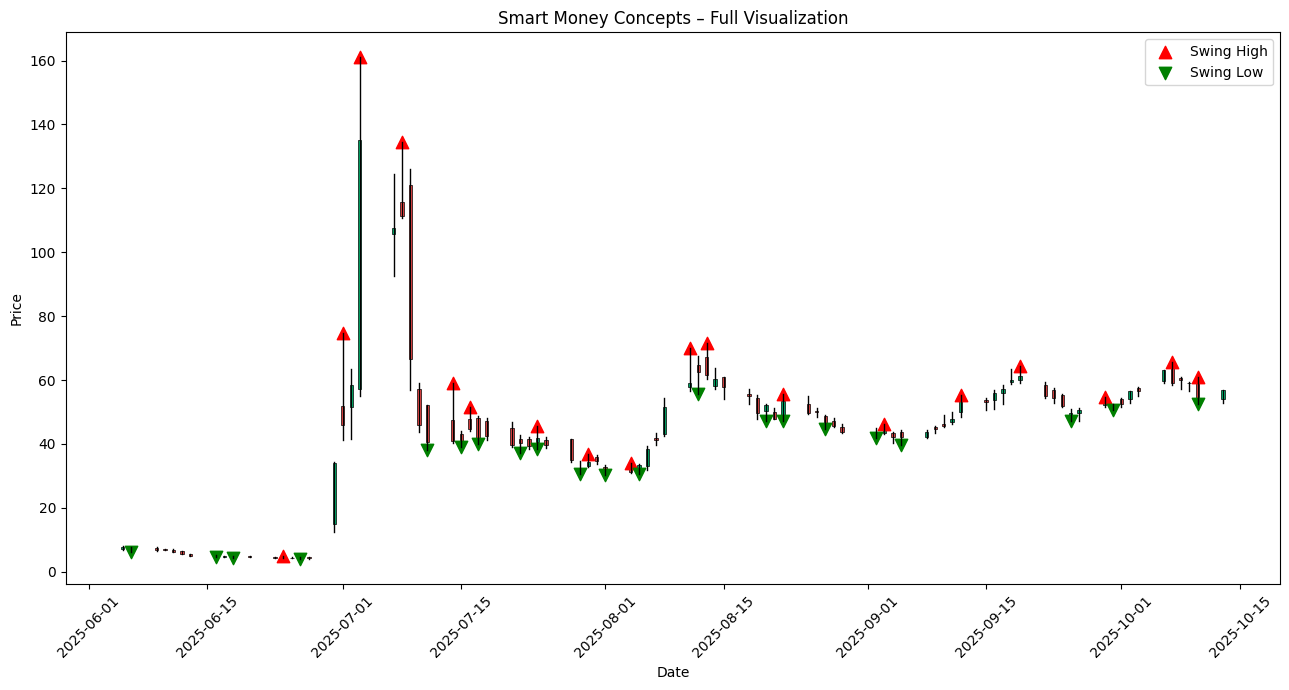

In [117]:
# Show everything
plot_smc_chart(
    df,
    show_candles=True,
    show_swings=True,
    show_bos=False,
    show_order_blocks=False,
    show_equal_high_low=False,
    show_fvg=False,
    show_zones=False
)


BOLLINGER BANDS - ANALYSIS

📊 SUMMARY: MID-RANGE. Price $56.85, Basis $55.87, %B: 56.5%.

💼 POSITION: Current: $56.85. Moving Mean (Basis): $55.87 (+1.8%). Upper: $63.48 (+11.7%), Lower: $48.26 (+15.1%).

📊 STD ANALYSIS: Moving Std: $3.81. Bandwidth: 27.25% (Avg: 154.21%). Price is +0.26σ from mean.

📈 %B: %B: 56.5%. Within normal range.

📉 VOLATILITY: SQUEEZE: Bandwidth 27.25% is -82.3% below average. Low volatility.

🔄 BANDS: 5 upper touches vs 0 lower - uptrend bias.

💰 PERFORMANCE: MODERATE: 49.3% win rate, -0.0% return, Sharpe 0.62.



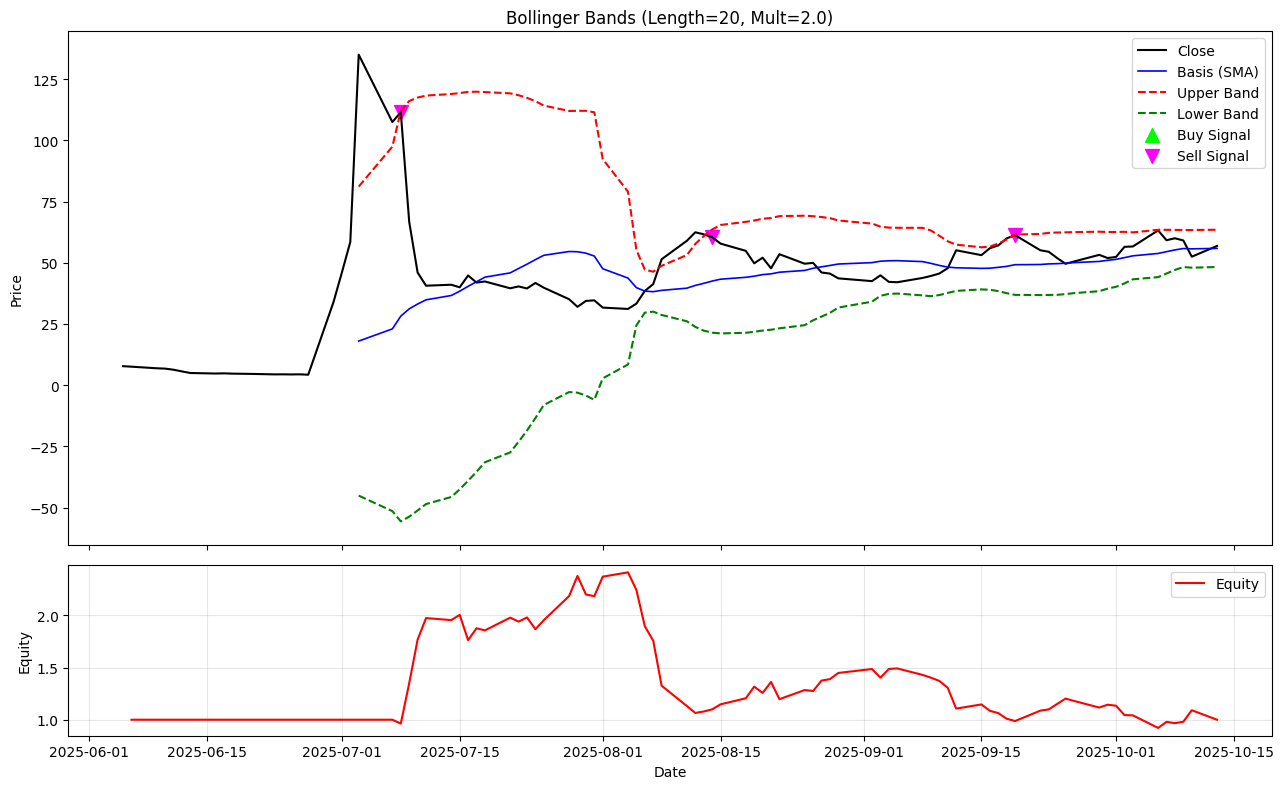

In [127]:
from Tech_Index.bollinger import bollinger_strategy, graph

result = bollinger_strategy(df)
graph(result)